In [ ]:
# ============================================================
# CELL 1 – Library Imports & Global Matplotlib Settings
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("✅ Libraries loaded!")

✅ Libraries loaded!


In [ ]:
# ============================================================
# CELL 2 – Synthetic Dataset Generation
# ============================================================
np.random.seed(42)
N = 5000

STATES  = ['Punjab','Haryana','Maharashtra','Karnataka','Tamil Nadu',
           'Uttar Pradesh','Andhra Pradesh','Gujarat','Rajasthan','West Bengal']
CROPS   = ['Rice','Wheat','Maize','Cotton','Sugarcane','Soybean','Groundnut','Barley']
SEASONS = ['Kharif','Rabi','Zaid']

state  = np.random.choice(STATES,  N)
crop   = np.random.choice(CROPS,   N)
season = np.random.choice(SEASONS, N)
year   = np.random.randint(1997, 2021, N)

avg_temp_c        = np.random.normal(28, 6, N).clip(10, 45)
total_rainfall_mm = np.random.exponential(160, N).clip(20, 800)
avg_humidity_pct  = np.random.normal(65, 15, N).clip(25, 98)
N_soil = np.random.normal(60,  20, N).clip(10, 140)
P_soil = np.random.normal(40,  15, N).clip(5,  100)
K_soil = np.random.normal(50,  18, N).clip(5,  130)
ph     = np.random.normal(6.5, 0.8, N).clip(4.5, 8.5)
area       = np.random.exponential(5000, N).clip(100, 100_000)
fertilizer = np.random.normal(150, 60, N).clip(20, 500)
pesticide  = np.random.normal(2.5, 1.2, N).clip(0.1, 10)

# Agronomically-motivated yield formula
raw_yield = (2800
             - 0.9*(avg_temp_c - 27)**2
             + 0.06*total_rainfall_mm
             - 0.00015*total_rainfall_mm**2
             + 3.5*avg_humidity_pct
             + 2.8*N_soil + 1.9*P_soil + 2.2*K_soil
             + 0.45*fertilizer
             + np.random.normal(0, 280, N))
yield_kgha = raw_yield.clip(400, 9000)

extreme_weather = (total_rainfall_mm > 350).astype(int)

df = pd.DataFrame({
    "state": state, "crop": crop, "season": season, "year": year,
    "avg_temp_c": avg_temp_c.round(2),
    "total_rainfall_mm": total_rainfall_mm.round(2),
    "avg_humidity_pct": avg_humidity_pct.round(2),
    "N": N_soil.round(2), "P": P_soil.round(2), "K": K_soil.round(2),
    "ph": ph.round(2), "area_ha": area.round(1),
    "fertilizer_kg": fertilizer.round(2), "pesticide_kg": pesticide.round(3),
    "extreme_weather": extreme_weather,
    "yield_kgha": yield_kgha.round(2),
})

print(f"✅ Dataset ready  →  Shape: {df.shape}")
print(f"   Extreme events : {extreme_weather.sum()} / {N}  ({extreme_weather.mean()*100:.1f}%)")
df.head()

✅ Dataset ready  →  Shape: (5000, 16)
   Extreme events : 598 / 5000  (12.0%)


,state,crop,season,year,avg_temp_c,total_rainfall_mm,avg_humidity_pct,N,P,K,ph,area_ha,fertilizer_kg,pesticide_kg,extreme_weather,yield_kgha
0,Andhra Pradesh,Groundnut,Zaid,2003,20.54,34.32,60.59,35.11,34.24,48.62,8.46,313.1,169.24,4.098,0,3472.76
1,Karnataka,Soybean,Zaid,1997,23.69,132.21,75.39,62.76,59.91,46.18,7.77,16822.3,109.30,4.479,0,3798.11
2,Gujarat,Cotton,Rabi,2001,28.71,20.00,65.08,73.82,22.45,35.74,6.53,4103.2,62.91,3.869,0,3436.16
3,Tamil Nadu,Maize,Kharif,2006,21.21,68.46,56.13,38.49,44.49,45.40,6.67,8390.9,101.23,1.739,0,3298.42
4,Andhra Pradesh,Sugarcane,Kharif,2018,34.39,40.96,62.77,37.84,22.23,54.52,5.61,7403.0,167.08,1.888,0,3357.08


In [ ]:
# ============================================================
# CELL 3 – Exploratory Summary Statistics
# ============================================================
print("="*55, "\nDATASET SUMMARY\n" + "="*55)
print(df.describe().round(2).to_string())
print("\nMissing values:", df.isnull().sum().sum())
print("\nCrop distribution:\n", df['crop'].value_counts().to_string())

DATASET SUMMARY
          year  avg_temp_c  total_rainfall_mm  avg_humidity_pct        N        P        K       ph   area_ha  fertilizer_kg  pesticide_kg  extreme_weather  yield_kgha
count  5000.00     5000.00            5000.00           5000.00  5000.00  5000.00  5000.00  5000.00   5000.00        5000.00       5000.00          5000.00     5000.00
mean   2008.76       28.03             164.97             65.00    60.24    40.07    49.79     6.52   5000.85         150.71          2.51             0.12     3419.42
std       6.94        6.03             156.51             14.83    19.61    14.93    17.78     0.79   5024.71          59.22          1.20             0.32      298.92
min    1997.00       10.00              20.00             25.00    10.00     5.00     5.00     4.50    100.00          20.00          0.10             0.00     2390.81
25%    2003.00       23.89              48.32             54.82    46.30    29.81    37.38     5.97   1503.78         110.39          1.68      

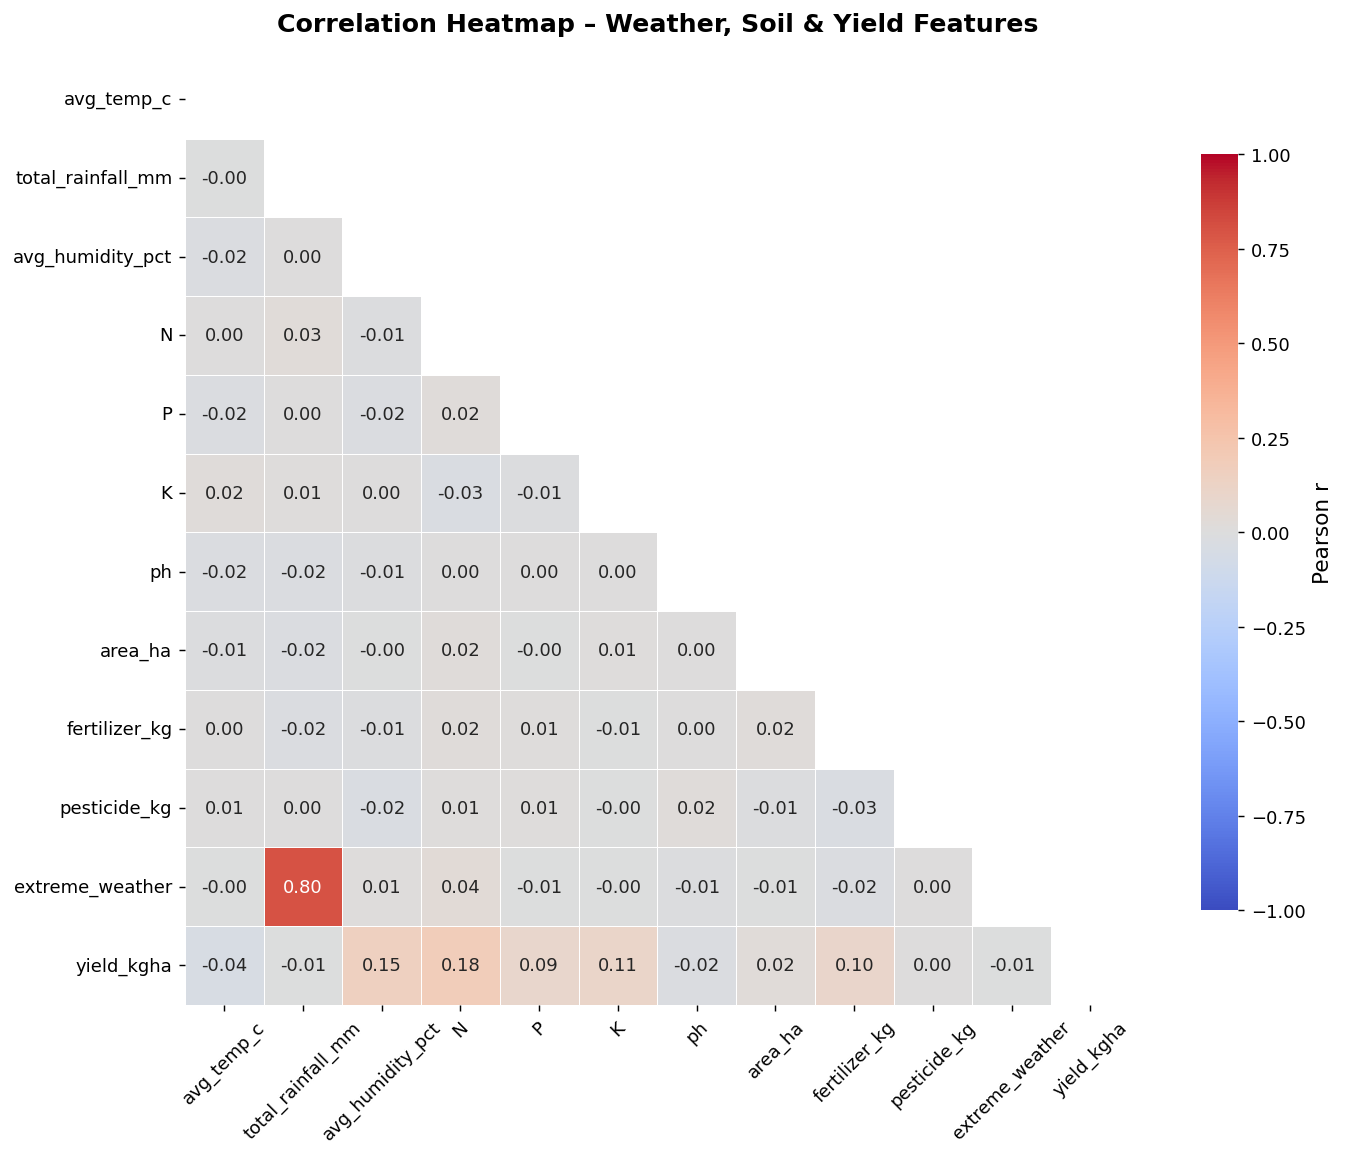

✅ heatmap.png saved


In [ ]:
# ============================================================
# CELL 4 – Feature Correlation Heatmap
# ============================================================
num_cols = ["avg_temp_c","total_rainfall_mm","avg_humidity_pct",
            "N","P","K","ph","area_ha","fertilizer_kg",
            "pesticide_kg","extreme_weather","yield_kgha"]

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
            square=True, ax=ax, cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax.set_title("Correlation Heatmap – Weather, Soil & Yield Features", pad=16)
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", rotation=0,  labelsize=10)
plt.tight_layout()
plt.savefig("heatmap.png", bbox_inches="tight")
plt.show()
print("✅ heatmap.png saved")

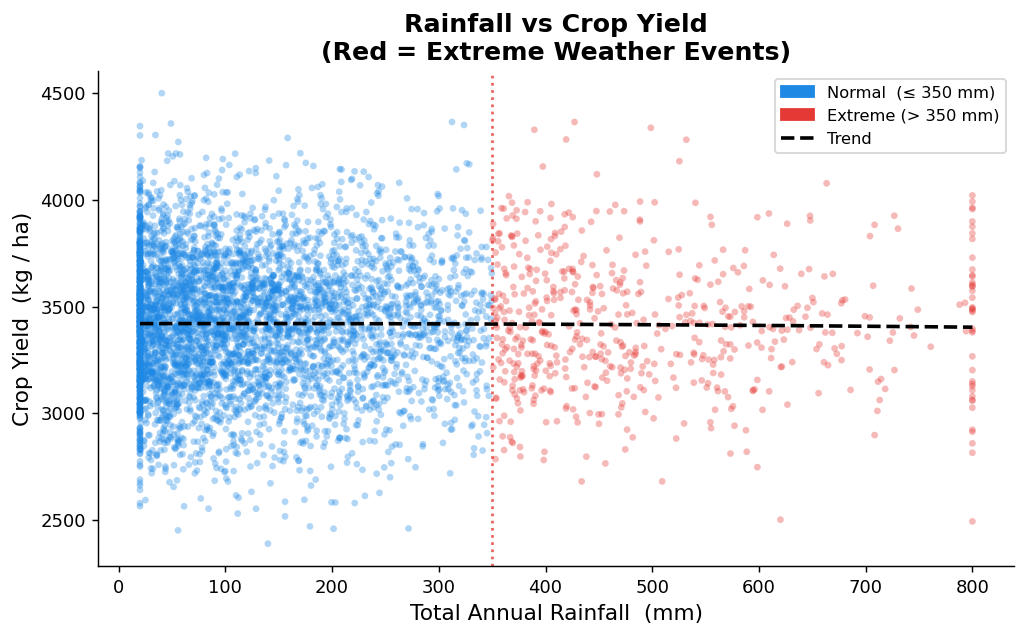

In [ ]:
# ============================================================
# CELL 5 – Rainfall vs Crop Yield Scatter Plot
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
colors = np.where(df["extreme_weather"]==1, "#E53935", "#1E88E5")
ax.scatter(df["total_rainfall_mm"], df["yield_kgha"],
           c=colors, alpha=0.35, s=14, edgecolors="none")

z = np.polyfit(df["total_rainfall_mm"], df["yield_kgha"], 2)
xs = np.linspace(df["total_rainfall_mm"].min(), df["total_rainfall_mm"].max(), 300)
ax.plot(xs, np.poly1d(z)(xs), color="black", lw=2, linestyle="--", label="Trend (poly-2)")
ax.axvline(350, color="#E53935", lw=1.5, linestyle=":", alpha=0.8, label="Extreme threshold 350 mm")

patch_n = mpatches.Patch(color="#1E88E5", label="Normal  (≤ 350 mm)")
patch_e = mpatches.Patch(color="#E53935", label="Extreme (> 350 mm)")
ax.legend(handles=[patch_n, patch_e,
          plt.Line2D([],[],color="black",ls="--",lw=2,label="Trend")], fontsize=9)
ax.set_xlabel("Total Annual Rainfall  (mm)")
ax.set_ylabel("Crop Yield  (kg / ha)")
ax.set_title("Rainfall vs Crop Yield\n(Red = Extreme Weather Events)")
plt.tight_layout()
plt.savefig("scatter_rainfall_yield.png", bbox_inches="tight")
plt.show()

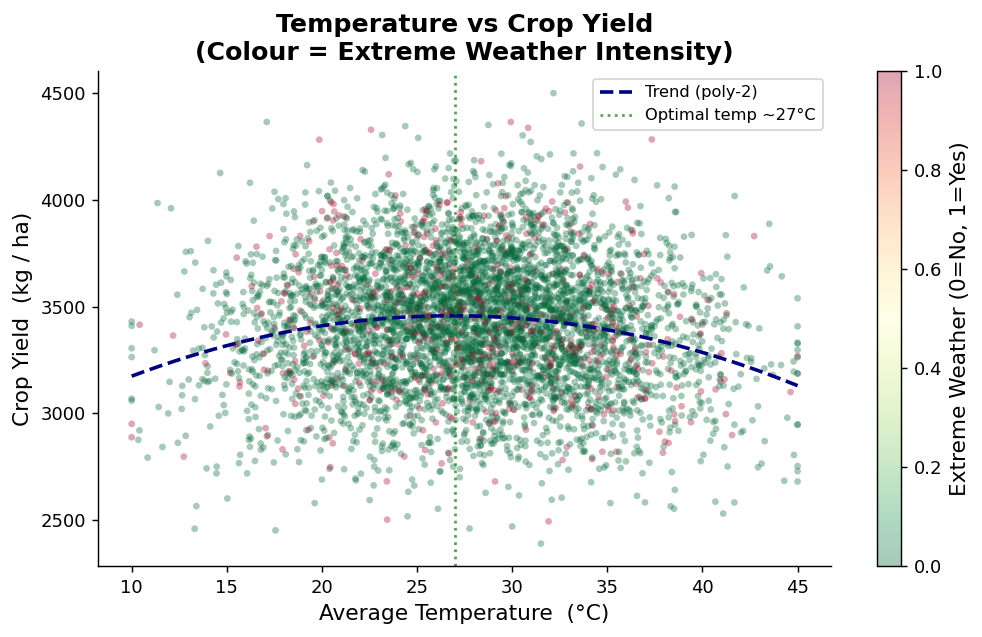

In [ ]:
# ============================================================
# CELL 6 – Temperature vs Crop Yield Scatter Plot
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(df["avg_temp_c"], df["yield_kgha"],
                c=df["extreme_weather"], cmap="RdYlGn_r",
                alpha=0.35, s=14, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Extreme Weather (0=No, 1=Yes)")

z2 = np.polyfit(df["avg_temp_c"], df["yield_kgha"], 2)
xs2 = np.linspace(df["avg_temp_c"].min(), df["avg_temp_c"].max(), 300)
ax.plot(xs2, np.poly1d(z2)(xs2), color="navy", lw=2, linestyle="--", label="Trend (poly-2)")
ax.axvline(27, color="green", lw=1.5, linestyle=":", alpha=0.7, label="Optimal temp ~27°C")

ax.set_xlabel("Average Temperature  (°C)")
ax.set_ylabel("Crop Yield  (kg / ha)")
ax.set_title("Temperature vs Crop Yield\n(Colour = Extreme Weather Intensity)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("scatter_temp_yield.png", bbox_inches="tight")
plt.show()

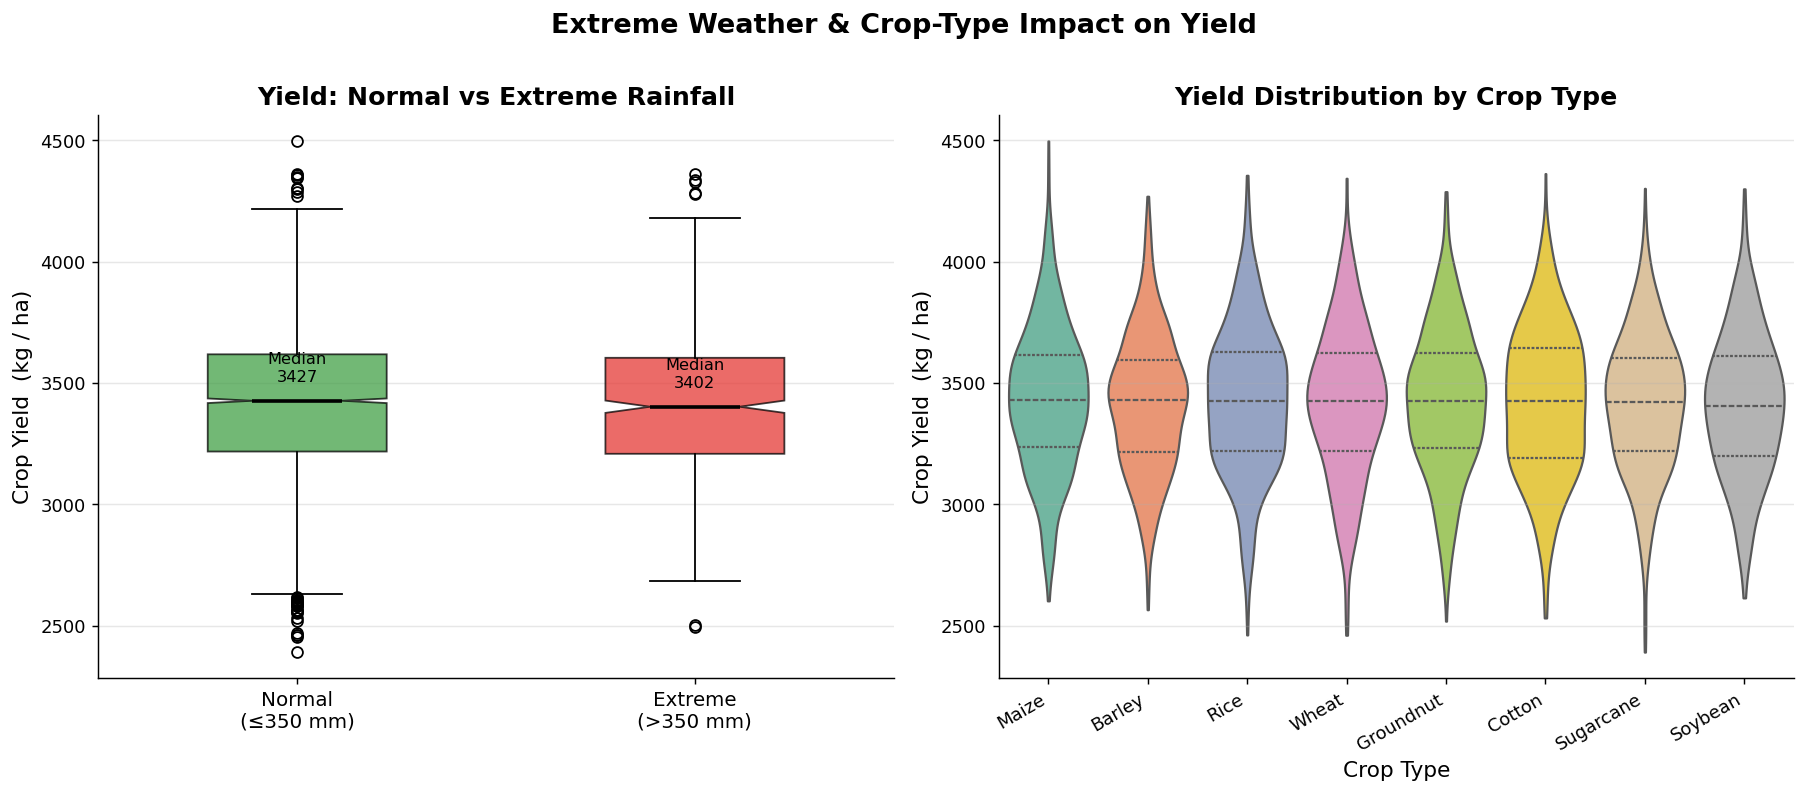

In [ ]:
# ============================================================
# CELL 7 – Box Plot (Extreme vs Normal) & Violin Plot (by Crop)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Box plot: Normal vs Extreme ---
data_groups = [df[df["extreme_weather"]==g]["yield_kgha"].values for g in [0,1]]
bp = axes[0].boxplot(data_groups, patch_artist=True, notch=True, widths=0.45,
                     medianprops=dict(color="black", lw=2))
for patch, clr in zip(bp["boxes"], ["#43A047","#E53935"]):
    patch.set_facecolor(clr); patch.set_alpha(0.75)
axes[0].set_xticks([1,2])
axes[0].set_xticklabels(["Normal\n(≤350 mm)", "Extreme\n(>350 mm)"], fontsize=11)
axes[0].set_ylabel("Crop Yield  (kg / ha)")
axes[0].set_title("Yield: Normal vs Extreme Rainfall")
axes[0].grid(axis="y", alpha=0.3)
for i, d in enumerate(data_groups, 1):
    axes[0].text(i, np.median(d)+80, f"Median\n{np.median(d):.0f}",
                 ha="center", fontsize=9)

# --- Violin plot: by crop type ---
crop_order = df.groupby("crop")["yield_kgha"].median().sort_values(ascending=False).index
sns.violinplot(data=df, x="crop", y="yield_kgha", order=crop_order,
               palette="Set2", inner="quartile", ax=axes[1], cut=0)
axes[1].set_xticklabels(crop_order, rotation=30, ha="right", fontsize=10)
axes[1].set_xlabel("Crop Type"); axes[1].set_ylabel("Crop Yield  (kg / ha)")
axes[1].set_title("Yield Distribution by Crop Type")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Extreme Weather & Crop-Type Impact on Yield",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("boxplot_extreme_crop.png", bbox_inches="tight")
plt.show()

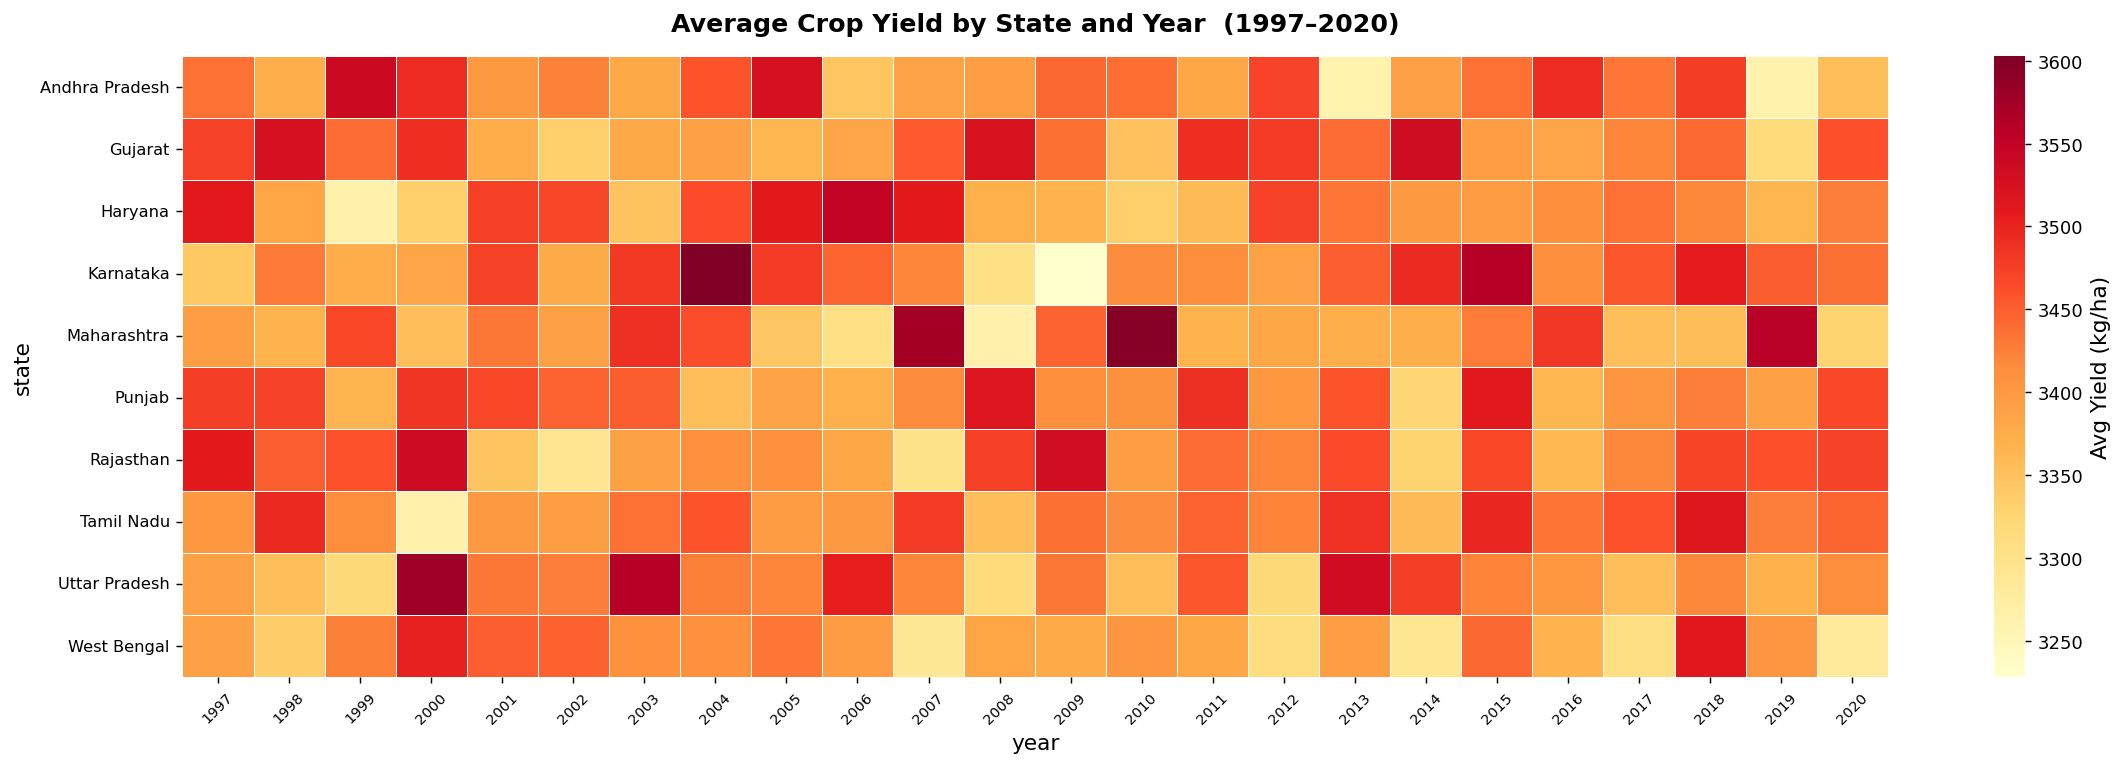

In [ ]:
# ============================================================
# CELL 8 – State × Year Average Yield Heatmap
# ============================================================
pivot = df.pivot_table(values="yield_kgha", index="state",
                        columns="year", aggfunc="mean")
fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, linecolor="white",
            ax=ax, cbar_kws={"label": "Avg Yield (kg/ha)"})
ax.set_title("Average Crop Yield by State and Year  (1997–2020)", pad=14)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig("heatmap_state_year.png", bbox_inches="tight")
plt.show()

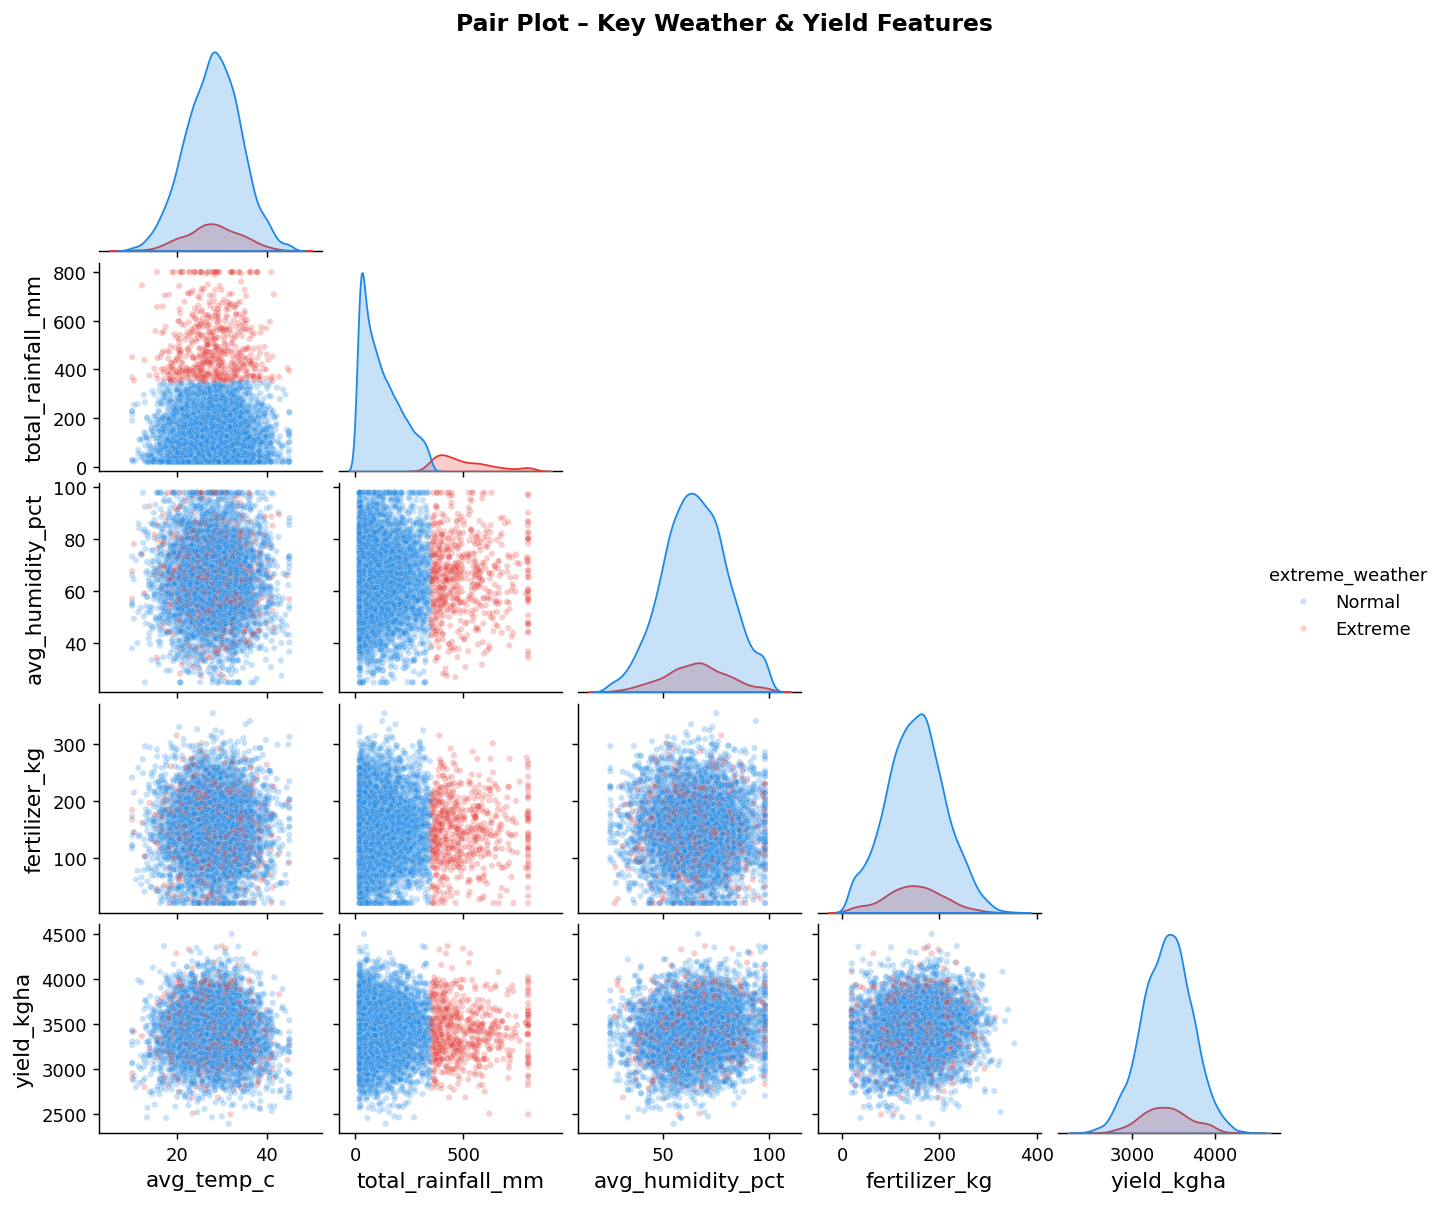

In [ ]:
# ============================================================
# CELL 9 – Pair Plot of Key Weather & Yield Features
# ============================================================
pair_df = df[["avg_temp_c","total_rainfall_mm","avg_humidity_pct",
               "fertilizer_kg","yield_kgha","extreme_weather"]].copy()
pair_df["extreme_weather"] = pair_df["extreme_weather"].map({0:"Normal",1:"Extreme"})

g = sns.pairplot(pair_df, hue="extreme_weather",
                 palette={"Normal":"#1E88E5","Extreme":"#E53935"},
                 plot_kws=dict(alpha=0.25, s=12),
                 diag_kind="kde",
                 vars=["avg_temp_c","total_rainfall_mm","avg_humidity_pct",
                       "fertilizer_kg","yield_kgha"],
                 corner=True)
g.figure.suptitle("Pair Plot – Key Weather & Yield Features", y=1.01, fontsize=13, fontweight="bold")
g.figure.set_size_inches(11, 9)
plt.savefig("pairplot.png", bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# CELL 10 – ML Pre-processing: Encoding & Train/Test Split
# ============================================================
df_ml = df.copy()
le = {}
for col in ["state", "crop", "season"]:
    le[col] = LabelEncoder()
    df_ml[col] = le[col].fit_transform(df_ml[col])

FEATURES = ["year","avg_temp_c","total_rainfall_mm","avg_humidity_pct",
            "N","P","K","ph","area_ha","fertilizer_kg","pesticide_kg",
            "crop","season","state","extreme_weather"]
TARGET = "yield_kgha"

X = df_ml[FEATURES]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)
print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows  |  Features: {len(FEATURES)}")

Train: 4000 rows  |  Test: 1000 rows  |  Features: 15


In [ ]:
# ============================================================
# CELL 11 – Model Training & Evaluation
# ============================================================
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    preds = mdl.predict(X_test)
    results[name] = {
        "model": mdl, "preds": preds,
        "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 2),
        "MAE":  round(mean_absolute_error(y_test, preds), 2),
        "R2":   round(r2_score(y_test, preds), 4),
    }
    print(f"{name:25s}  RMSE={results[name]['RMSE']:7.2f}  MAE={results[name]['MAE']:7.2f}  R²={results[name]['R2']:.4f}")

best_name  = max(results, key=lambda k: results[k]["R2"])
best_model = results[best_name]["model"]
y_pred     = results[best_name]["preds"]
print(f"\n🏆 Best model: {best_name}  (R² = {results[best_name]['R2']})")

Linear Regression          RMSE= 286.26  MAE= 228.76  R²=0.0720
Random Forest              RMSE= 283.56  MAE= 225.95  R²=0.0894
Gradient Boosting          RMSE= 285.80  MAE= 227.59  R²=0.0750

🏆 Best model: Random Forest  (R² = 0.0894)


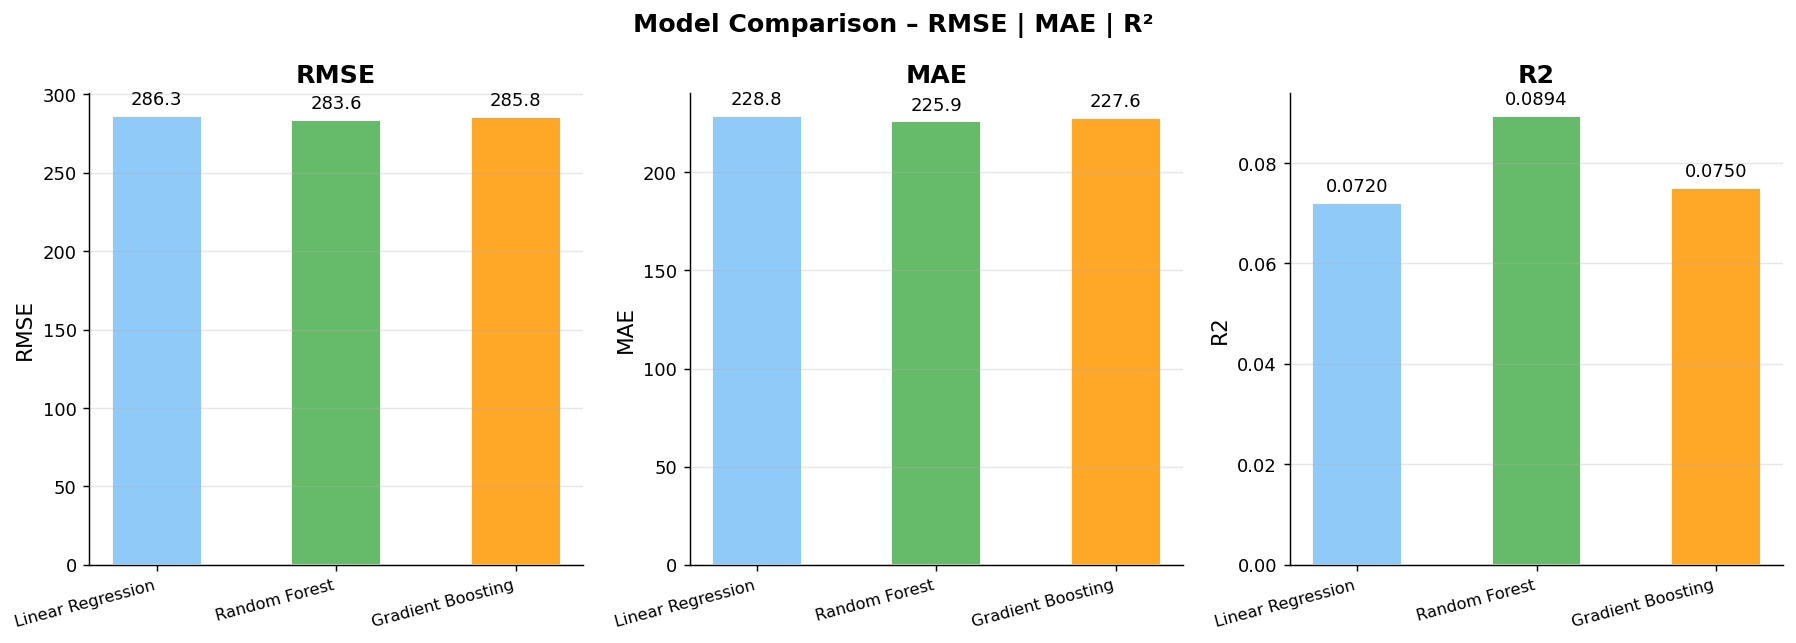

In [ ]:
# ============================================================
# CELL 12 – Model Comparison Bar Chart (RMSE / MAE / R²)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ["RMSE","MAE","R2"]):
    vals  = [results[m][metric] for m in results]
    names = list(results.keys())
    bars  = ax.bar(names, vals, color=["#90CAF9","#66BB6A","#FFA726"],
                   edgecolor="white", width=0.5)
    ax.bar_label(bars, fmt="%.4f" if metric=="R2" else "%.1f", padding=4, fontsize=10)
    ax.set_title(metric); ax.set_ylabel(metric)
    ax.set_xticklabels(names, rotation=15, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Model Comparison – RMSE | MAE | R²", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.show()

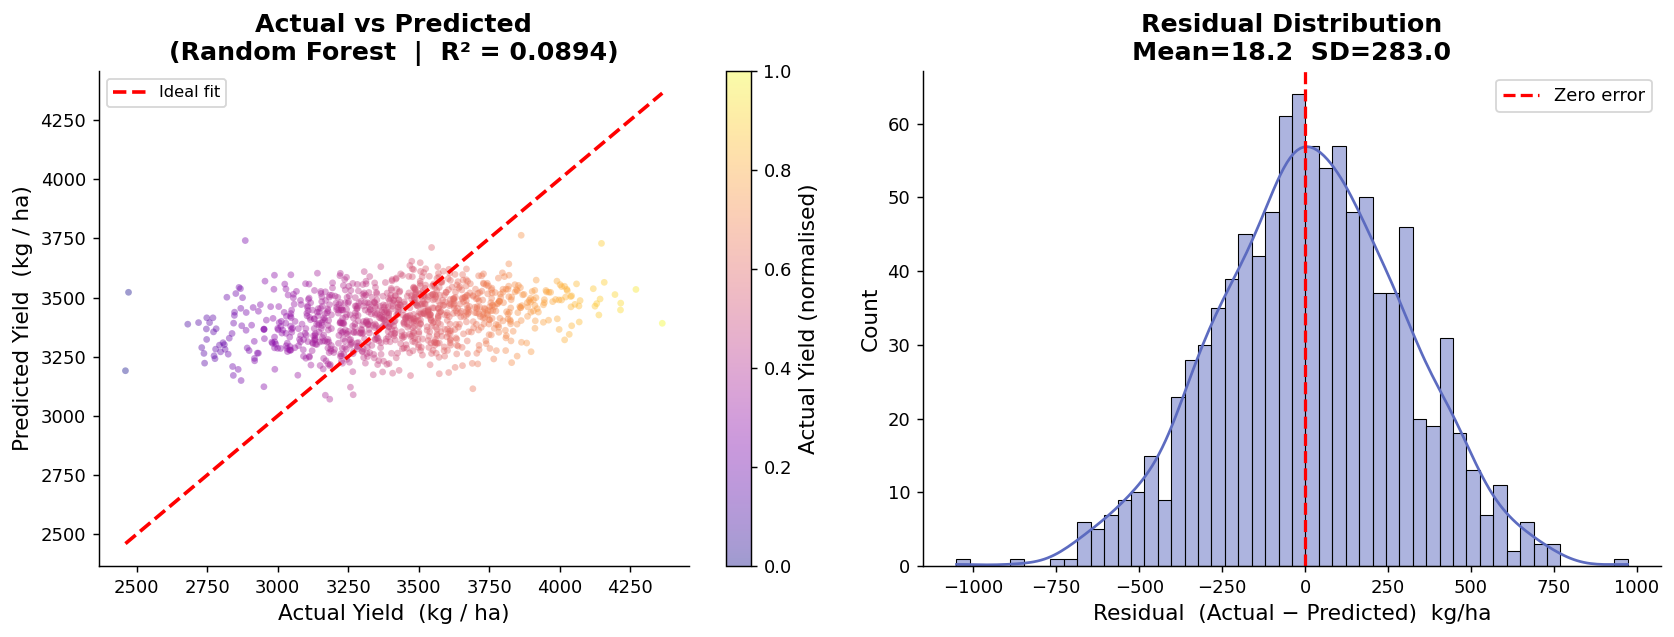

In [ ]:
# ============================================================
# CELL 13 – Actual vs Predicted & Residual Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
cmap_vals = (y_test.values - y_test.min()) / (y_test.max() - y_test.min())
sc = axes[0].scatter(y_test, y_pred, c=cmap_vals, cmap="plasma",
                     alpha=0.4, s=14, edgecolors="none")
plt.colorbar(sc, ax=axes[0], label="Actual Yield (normalised)")
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
axes[0].plot([lo,hi],[lo,hi],"r--",lw=2,label="Ideal fit")
axes[0].set_xlabel("Actual Yield  (kg / ha)")
axes[0].set_ylabel("Predicted Yield  (kg / ha)")
axes[0].set_title(f"Actual vs Predicted\n({best_name}  |  R² = {results[best_name]['R2']})")
axes[0].legend(fontsize=9)

# Residuals
residuals = y_test.values - y_pred
sns.histplot(residuals, kde=True, bins=50, color="#5C6BC0", ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--", lw=1.8, label="Zero error")
axes[1].set_xlabel("Residual  (Actual − Predicted)  kg/ha")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution\nMean={residuals.mean():.1f}  SD={residuals.std():.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", bbox_inches="tight")
plt.show()

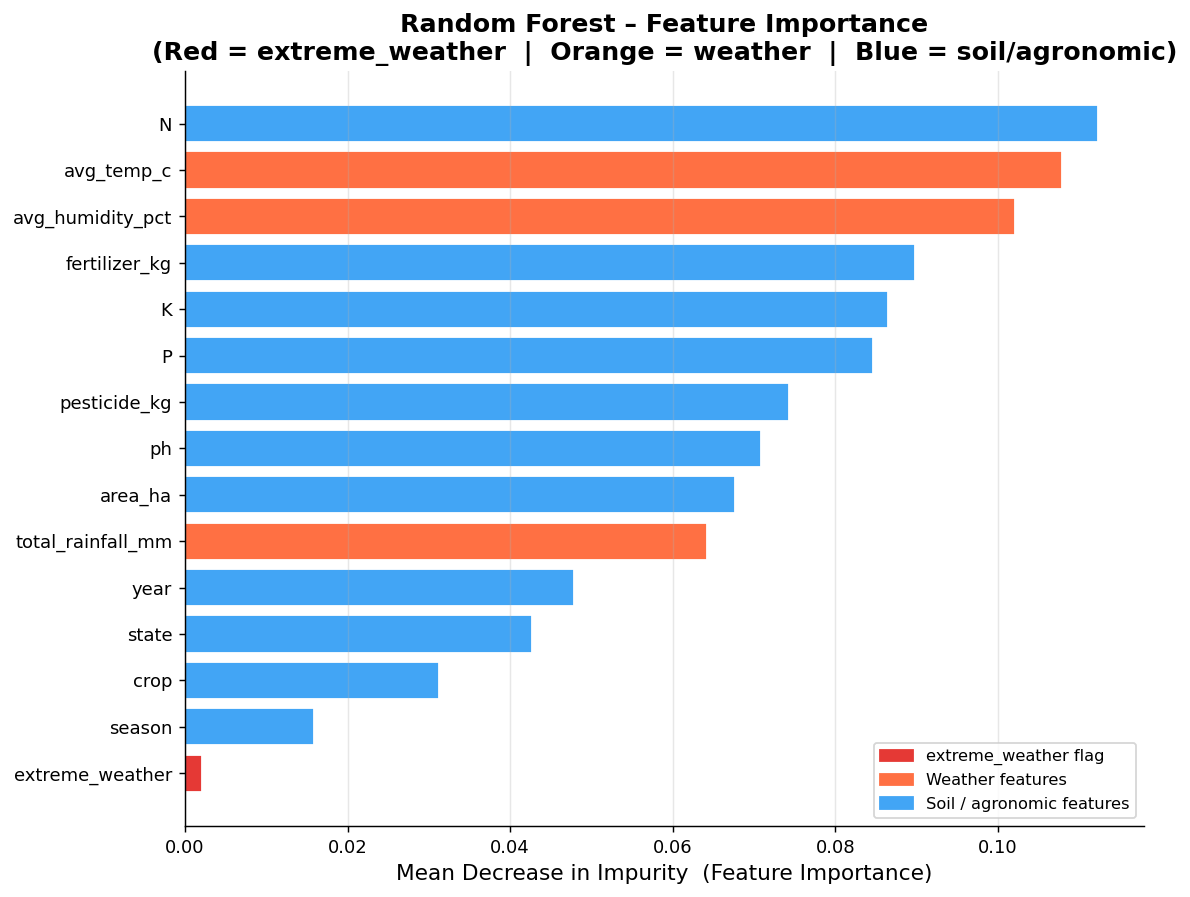

In [ ]:
# ============================================================
# CELL 14 – Random Forest Feature Importance
# ============================================================
rf_model = results["Random Forest"]["model"]
feat_df = pd.DataFrame({"Feature": FEATURES,
                         "Importance": rf_model.feature_importances_})
feat_df = feat_df.sort_values("Importance", ascending=True)

bar_colors = ["#E53935" if f=="extreme_weather" else
              "#FF7043" if f in ["total_rainfall_mm","avg_temp_c","avg_humidity_pct"] else
              "#42A5F5" for f in feat_df["Feature"]]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(feat_df["Feature"], feat_df["Importance"],
        color=bar_colors, edgecolor="white")
ax.set_xlabel("Mean Decrease in Impurity  (Feature Importance)")
ax.set_title("Random Forest – Feature Importance\n(Red = extreme_weather  |  Orange = weather  |  Blue = soil/agronomic)")
ax.grid(axis="x", alpha=0.3)
patches = [mpatches.Patch(color="#E53935", label="extreme_weather flag"),
           mpatches.Patch(color="#FF7043", label="Weather features"),
           mpatches.Patch(color="#42A5F5", label="Soil / agronomic features")]
ax.legend(handles=patches, fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()

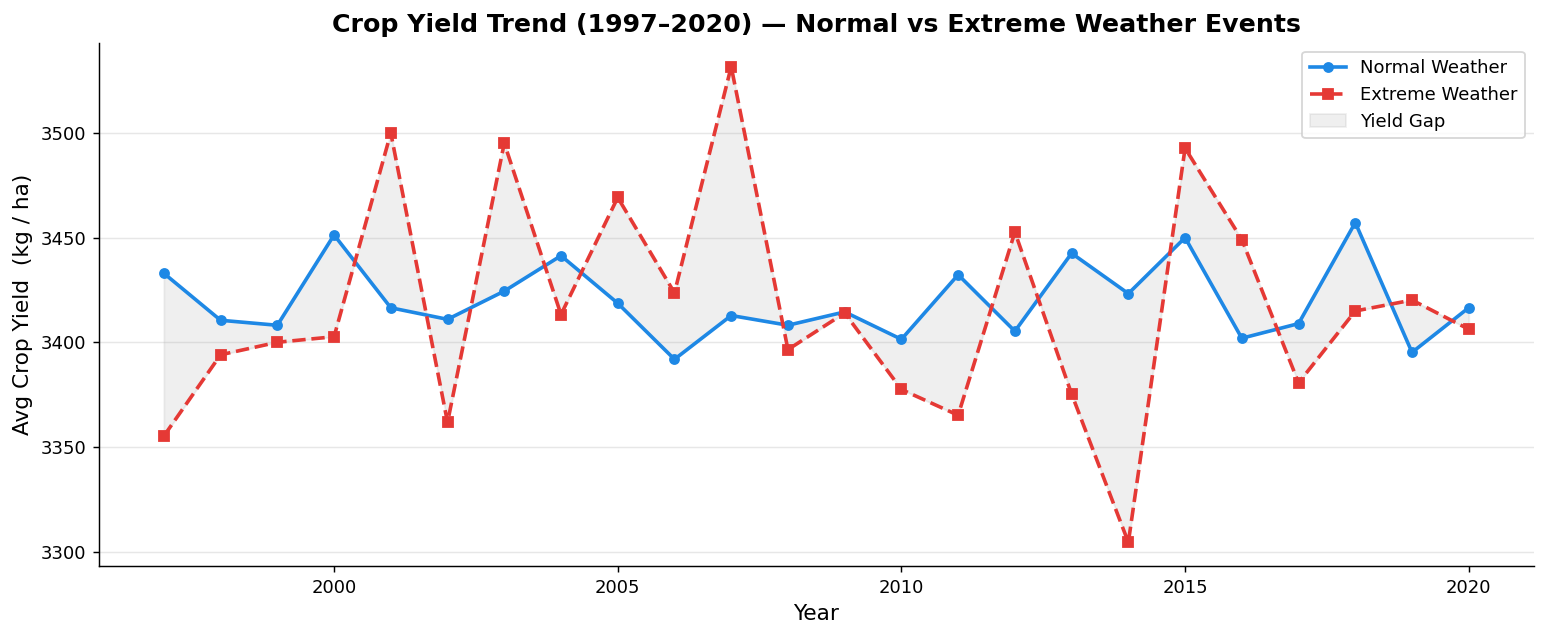

In [ ]:
# ============================================================
# CELL 15 – Crop Yield Trend (1997–2020): Normal vs Extreme Weather
# ============================================================
trend   = df.groupby(["year","extreme_weather"])["yield_kgha"].mean().reset_index()
normal  = trend[trend["extreme_weather"]==0].set_index("year")
extreme = trend[trend["extreme_weather"]==1].set_index("year")
common  = normal.index.intersection(extreme.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(normal.index,  normal["yield_kgha"],
        marker="o", ms=5, color="#1E88E5", lw=2, label="Normal Weather")
ax.plot(extreme.index, extreme["yield_kgha"],
        marker="s", ms=5, color="#E53935", lw=2, ls="--", label="Extreme Weather")
ax.fill_between(common,
                normal.loc[common,"yield_kgha"],
                extreme.loc[common,"yield_kgha"],
                alpha=0.12, color="gray", label="Yield Gap")
ax.set_xlabel("Year"); ax.set_ylabel("Avg Crop Yield  (kg / ha)")
ax.set_title("Crop Yield Trend (1997–2020) — Normal vs Extreme Weather Events")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("yield_trend.png", bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# CELL 16 – Save Dataset to CSV & Print Output File Summary
# ============================================================
df.to_csv("crop_yield_extreme_weather.csv", index=False)
print("✅ Saved: crop_yield_extreme_weather.csv")

# Uncomment to download in Colab:
# from google.colab import files
# files.download("crop_yield_extreme_weather.csv")

print("\n" + "="*55)
print("  ALL SAVED OUTPUTS")
print("="*55)
outputs = [
    ("heatmap.png",                "Feature correlation heatmap"),
    ("heatmap_state_year.png",     "Yield by State × Year"),
    ("scatter_rainfall_yield.png", "Rainfall vs Yield scatter"),
    ("scatter_temp_yield.png",     "Temperature vs Yield scatter"),
    ("boxplot_extreme_crop.png",   "Box + Violin plots"),
    ("pairplot.png",               "Pair plot of key features"),
    ("model_comparison.png",       "RMSE / MAE / R² comparison"),
    ("actual_vs_predicted.png",    "Actual vs Predicted + Residuals"),
    ("feature_importance.png",     "Random Forest feature importance"),
    ("yield_trend.png",            "Yield trend 1997–2020"),
    ("crop_yield_extreme_weather.csv", "Full dataset  (5 000 rows)"),
]
for fname, desc in outputs:
    print(f"  {fname:40s} – {desc}")
print("="*55)

✅ Saved: crop_yield_extreme_weather.csv

  ALL SAVED OUTPUTS
  heatmap.png                              – Feature correlation heatmap
  heatmap_state_year.png                   – Yield by State × Year
  scatter_rainfall_yield.png               – Rainfall vs Yield scatter
  scatter_temp_yield.png                   – Temperature vs Yield scatter
  boxplot_extreme_crop.png                 – Box + Violin plots
  pairplot.png                             – Pair plot of key features
  model_comparison.png                     – RMSE / MAE / R² comparison
  actual_vs_predicted.png                  – Actual vs Predicted + Residuals
  feature_importance.png                   – Random Forest feature importance
  yield_trend.png                          – Yield trend 1997–2020
  crop_yield_extreme_weather.csv           – Full dataset  (5 000 rows)
